In [149]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [150]:
df_01 = pd.read_excel("../data/ref_data/CIV1159_W2026_FP_Task2data.xlsx", sheet_name="Structure 1")
df_02 = pd.read_excel("../data/ref_data/CIV1159_W2026_FP_Task2data.xlsx", sheet_name="Structure 2")
df_03 = pd.read_excel("../data/ref_data/CIV1159_W2026_FP_Task2data.xlsx", sheet_name="Structure 3")

In [151]:
# Assume the column is 'Date (ddmm)' and values are like '2506' (25th June)
date_str = df_01['Date (ddmm)'].astype(str).str.zfill(4)  # Pad with zeros if needed
day = date_str.str[:-2]  # All but last 2 chars
month = date_str.str[-2:]  # Last 2 chars



In [152]:
# Ensure all values are strings and 4 digits (e.g., '0106' for June 1)
df_01['Date (ddmm)'] = df_01['Date (ddmm)'].astype(str).str.zfill(4)
print (df_01['Date (ddmm)'])

df_02['Date (ddmm)'] = df_02['Date (ddmm)'].astype(str).str.zfill(4)
print (df_02['Date (ddmm)'])

df_03['Date (ddmm)'] = df_03['Date (ddmm)'].astype(str).str.zfill(4)
print (df_03['Date (ddmm)'])

0      0101
1      0201
2      0301
3      0401
4      0501
       ... 
360    2712
361    2812
362    2912
363    3012
364    3112
Name: Date (ddmm), Length: 365, dtype: object
0      0101
1      0201
2      0301
3      0401
4      0501
       ... 
360    2712
361    2812
362    2912
363    3012
364    3112
Name: Date (ddmm), Length: 365, dtype: object
0      0101
1      0201
2      0301
3      0401
4      0501
       ... 
360    2712
361    2812
362    2912
363    3012
364    3112
Name: Date (ddmm), Length: 365, dtype: object


In [153]:
for df in [df_01, df_02, df_03]:
    df['Date (ddmm)'] = pd.to_datetime(df['Date (ddmm)'].astype(str), format='%d%m')

In [154]:
df_01.head()

,Date (ddmm),Strain (με)
0,1900-01-01,292.8
1,1900-01-02,298.1
2,1900-01-03,295.5
3,1900-01-04,305.5
4,1900-01-05,297.7


In [155]:
df_02.head()

,Date (ddmm),Strain (με)
0,1900-01-01,97.4
1,1900-01-02,104.2
2,1900-01-03,104.4
3,1900-01-04,98.9
4,1900-01-05,106.1


In [156]:
df_03.head()

,Date (ddmm),Strain (με)
0,1900-01-01,87.4
1,1900-01-02,82.4
2,1900-01-03,86.4
3,1900-01-04,82.3
4,1900-01-05,93.9


In [157]:
# Rename value columns
df_01 = df_01.rename(columns={'Strain (με)': 'strain(με)_structure_01'})
df_02 = df_02.rename(columns={'Strain (με)': 'strain(με)_structure_02'})
df_03 = df_03.rename(columns={'Strain (με)': 'strain(με)_structure_03'})

# Merge on 'date'
df = df_01.merge(df_02, on='Date (ddmm)', how='inner').merge(df_03, on='Date (ddmm)', how='inner')

In [158]:
df.head()

,Date (ddmm),strain(με)_structure_01,strain(με)_structure_02,strain(με)_structure_03
0,1900-01-01,292.8,97.4,87.4
1,1900-01-02,298.1,104.2,82.4
2,1900-01-03,295.5,104.4,86.4
3,1900-01-04,305.5,98.9,82.3
4,1900-01-05,297.7,106.1,93.9


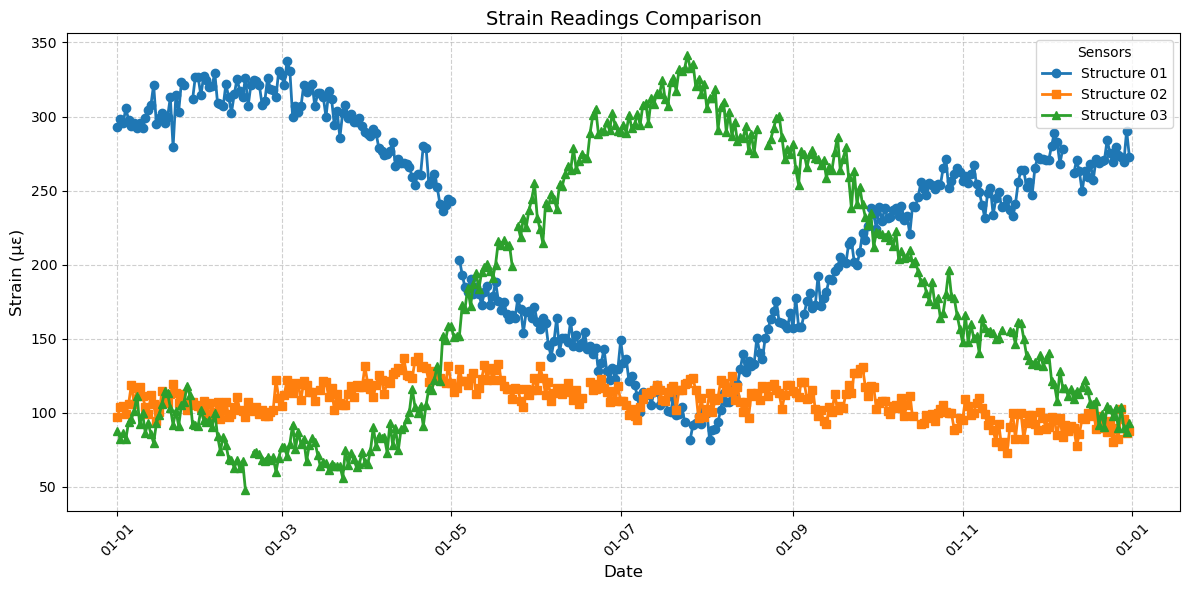

In [159]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# Sort by date just in case
df = df.sort_values('Date (ddmm)')

# Create figure
plt.figure(figsize=(12, 6))

# Plot the 3 strain readings
plt.plot(
    df['Date (ddmm)'],
    df['strain(με)_structure_01'],
    marker='o',
    linewidth=2,
    label='Structure 01'
)

plt.plot(
    df['Date (ddmm)'],
    df['strain(με)_structure_02'],
    marker='s',
    linewidth=2,
    label='Structure 02'
)

plt.plot(
    df['Date (ddmm)'],
    df['strain(με)_structure_03'],
    marker='^',
    linewidth=2,
    label='Structure 03'
)

# Titles and labels
plt.title('Strain Readings Comparison', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Strain (µε)', fontsize=12)

# Improve date formatting on x-axis
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())

# Formatting
plt.legend(title='Sensors')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

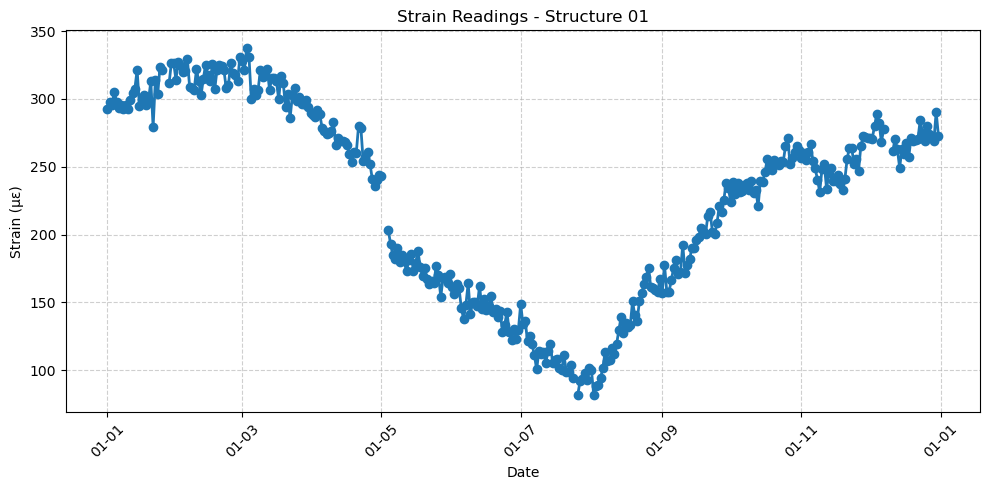

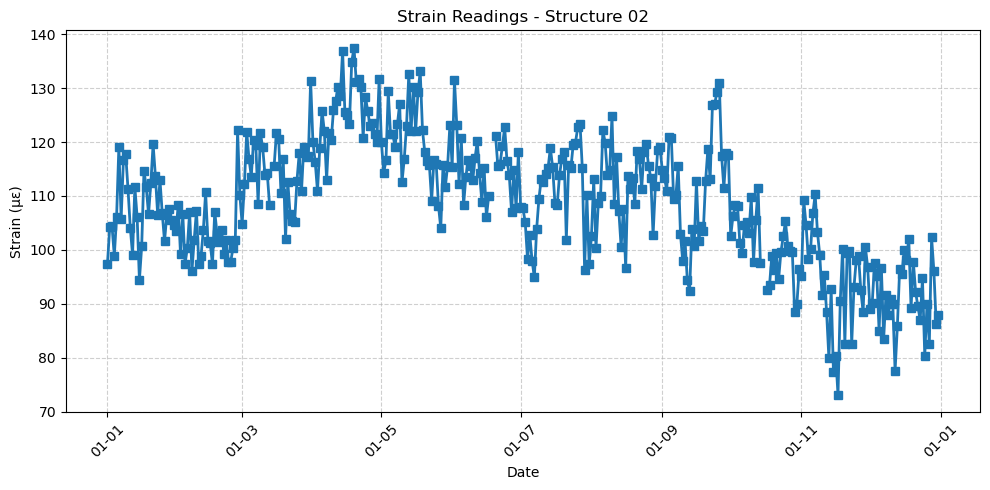

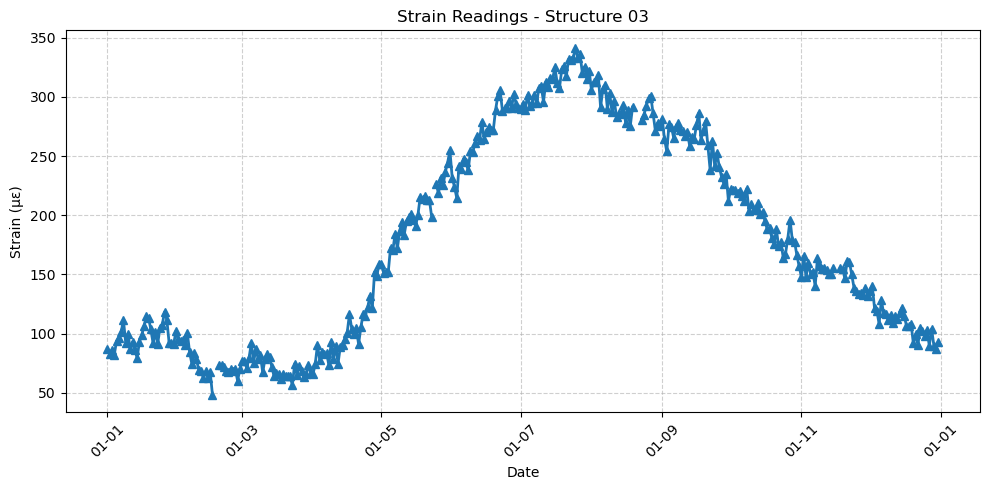

In [160]:
structures = [
    ('strain(με)_structure_01', 'Structure 01', 'o'),
    ('strain(με)_structure_02', 'Structure 02', 's'),
    ('strain(με)_structure_03', 'Structure 03', '^')
]

# Create one plot per structure using a loop
for col, title, marker in structures:
    plt.figure(figsize=(10, 5))
    plt.plot(
        df['Date (ddmm)'],
        df[col],
        marker=marker,
        linewidth=2
    )
    plt.title(f'Strain Readings - {title}')
    plt.xlabel('Date')
    plt.ylabel('Strain (µε)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [161]:
# Normalize the strain data for each structure (min-max normalization)
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
strain_cols = ['strain(με)_structure_01', 'strain(με)_structure_02', 'strain(με)_structure_03']
df_norm = df.copy()
df_norm[strain_cols] = scaler.fit_transform(df[strain_cols])

df_norm.head()

,Date (ddmm),strain(με)_structure_01,strain(με)_structure_02,strain(με)_structure_03
0,1900-01-01,0.824219,0.377329,0.133652
1,1900-01-02,0.844922,0.482919,0.116604
2,1900-01-03,0.834766,0.486025,0.130242
3,1900-01-04,0.873828,0.400621,0.116263
4,1900-01-05,0.843359,0.512422,0.155813


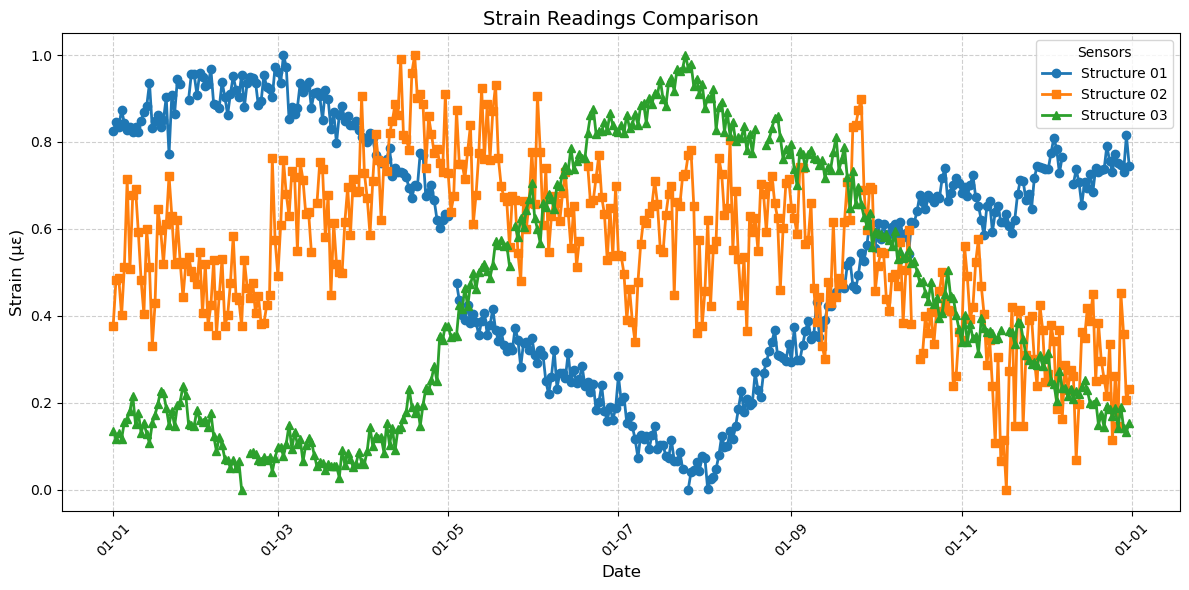

In [162]:
# Sort by date just in case
df_norm = df_norm.sort_values('Date (ddmm)')

# Create figure
plt.figure(figsize=(12, 6))

# Plot the 3 strain readings
plt.plot(
    df_norm['Date (ddmm)'],
    df_norm['strain(με)_structure_01'],
    marker='o',
    linewidth=2,
    label='Structure 01'
)

plt.plot(
    df_norm['Date (ddmm)'],
    df_norm['strain(με)_structure_02'],
    marker='s',
    linewidth=2,
    label='Structure 02'
)

plt.plot(
    df_norm['Date (ddmm)'],
    df_norm['strain(με)_structure_03'],
    marker='^',
    linewidth=2,
    label='Structure 03'
)

# Titles and labels
plt.title('Strain Readings Comparison', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Strain (µε)', fontsize=12)

# Improve date formatting on x-axis
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())

# Formatting
plt.legend(title='Sensors')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

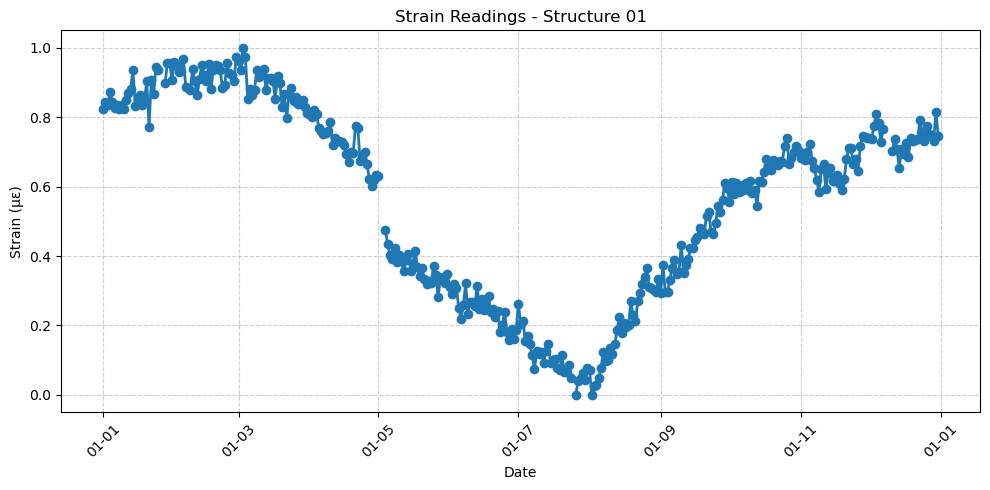

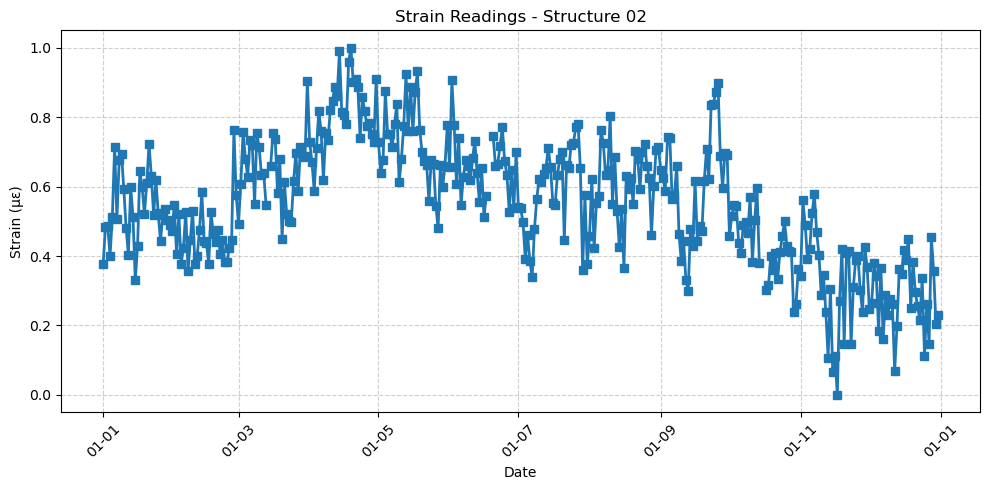

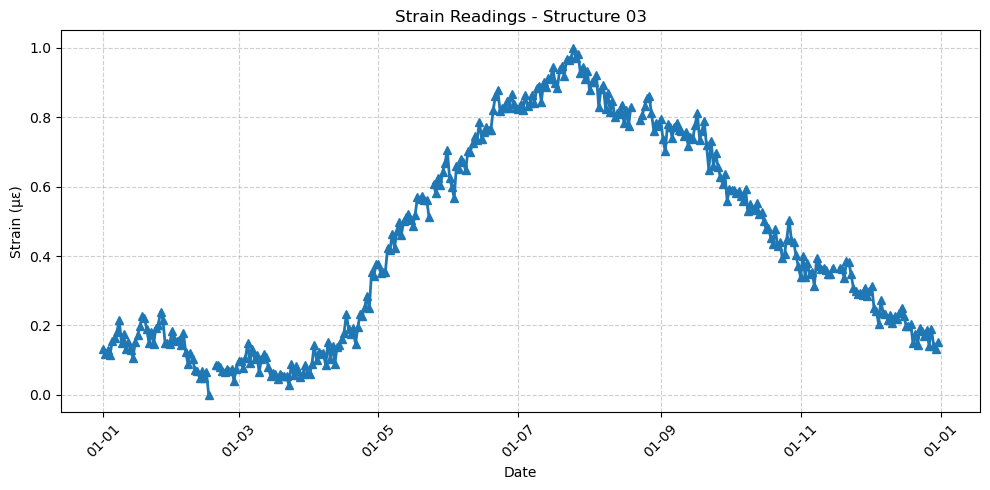

In [163]:
structures = [
    ('strain(με)_structure_01', 'Structure 01', 'o'),
    ('strain(με)_structure_02', 'Structure 02', 's'),
    ('strain(με)_structure_03', 'Structure 03', '^')
]

# Create one plot per structure using a loop
for col, title, marker in structures:
    plt.figure(figsize=(10, 5))
    plt.plot(
        df_norm['Date (ddmm)'],
        df_norm[col],
        marker=marker,
        linewidth=2
    )
    plt.title(f'Strain Readings - {title}')
    plt.xlabel('Date')
    plt.ylabel('Strain (µε)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()